---
tags: [algorithm, sample-based]
---

# Quantum Selected Configuration Interaction (QSCI)

**Quantum-Selected Configuration Interaction (QSCI)**
{cite:p}`10.1103/dmn4-snfx` is a hybrid quantum–classical algorithm
that uses bitstrings sampled from a quantum state to build a small
effective Hamiltonian and then diagonalizes it exactly on a classical
computer.
This tutorial implements the QSCI workflow with Qamomile for a
four-qubit transverse-field Ising model. Quantum state preparation and
sampling run on the Qulacs simulator through the QURI Parts integration.
Subspace construction and diagonalization use
`qamomile.linalg.solve_subspace`.

In [1]:
# Install the latest Qamomile with the QURI Parts and visualization extras through pip.
# !pip install "qamomile[quri_parts,visualization]"

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.circuit.algorithm.basic import cx_entangling_layer, ry_layer
from qamomile.linalg import solve_subspace
from qamomile.quri_parts import QuriPartsExecutor, QuriPartsTranspiler

docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"

## Problem Settings: One-Dimensional Transverse-Field Ising Model

We use the four-qubit transverse-field Ising model on a one-dimensional chain:

$$
H \;=\; -J \sum_{i=0}^{n-2} Z_i Z_{i+1} \;-\; h \sum_{i=0}^{n-1} X_i,
\quad J = 1,\; h = 0.7.
$$

The $2^4=16$-dimensional Hilbert space is small enough that we can compute
the exact ground-state energy directly with NumPy and use it as the
QSCI reference.

In [3]:
n_qubits = 4
J = 1.0
h_field = 0.7

H = qm_o.Hamiltonian(num_qubits=n_qubits)
for i in range(n_qubits - 1):
    H += qm_o.Z(i) * qm_o.Z(i + 1) * (-J)
for i in range(n_qubits):
    H += qm_o.X(i) * (-h_field)

exact_eigvals = np.linalg.eigvalsh(H.to_numpy())
E_exact = float(exact_eigvals[0])
print(f"Exact ground state energy: {E_exact:.6f}")
# eigvalsh returns ascending eigenvalues, so exact_eigvals[0] is the ground
# state. The 4-qubit TFIM Hilbert space is 2^n_qubits-dimensional.
assert H.num_qubits == n_qubits
assert exact_eigvals.shape == (2**n_qubits,)
assert E_exact == float(exact_eigvals.min())

Exact ground state energy: -3.872983


## Algorithm

**Quantum-Selected Configuration Interaction (QSCI)** is a hybrid
quantum–classical algorithm that estimates the ground-state energy by
measuring a quantum state prepared on a quantum computer in the
computational basis, selecting the most frequent bitstrings to form a
subspace, and classically diagonalizing the effective Hamiltonian within
that subspace.

The algorithm proposed by {cite:t}`10.1103/dmn4-snfx` proceeds as follows.

1. Prepare an input state $|\psi_{\mathrm{in}}\rangle$ on the quantum
   computer (typically a quantum state roughly optimised with VQE).
2. Measure $|\psi_{\mathrm{in}}\rangle$ in the computational basis many
   times.
3. Pick the top-$K$ most-frequent bitstrings as a discrete subspace
   $\{|s_i\rangle\}_{i=1}^{K}$.
4. Build the effective Hamiltonian
   $H^{\mathrm{sub}}_{ij} = \langle s_i | H | s_j \rangle$ and
   diagonalize it classically.

VQE {cite:p}`10.1038/ncomms5213` is widely known as a hybrid
quantum–classical algorithm for finding the ground state of a Hamiltonian.
Compared with VQE, QSCI has the advantage that its result inherits a strict
**variational guarantee**. Even on noisy hardware,

$$
E_{\mathrm{QSCI}} \;\geq\; E_{\mathrm{exact}}.
$$

Moreover, as the subspace size $K$ increases, the QSCI energy is
monotonically non-increasing and converges to the exact ground-state
energy.
Another feature of QSCI is that the quantum-state parameters do not need
to be fully optimised as they do in VQE. The input state
$|\psi_{\mathrm{in}}\rangle$ may use random parameters or parameters
roughly optimised with VQE. QSCI can increase the information captured by
the subspace as long as the input state's sampling distribution is
concentrated on the bitstrings that dominate the true ground state. This
advantage is particularly useful when VQE optimisation is difficult on
noisy hardware such as NISQ devices.


## Implementation with Qamomile

We now implement the QSCI workflow with Qamomile. Qamomile provides the
`solve_subspace` subroutine for implementing subspace methods such as QSCI.
`solve_subspace` takes a list of sampled bitstrings and a Hamiltonian,
constructs the effective Hamiltonian in the subspace, diagonalizes it
classically, and returns the eigenvalues and eigenvectors.

### VQE ansatz for initial-state preparation

We use a hardware-efficient ansatz for the QSCI input state. This is a
simple alternating-layer ansatz in which each layer applies $R_y$ to every
qubit followed by a linear chain of CNOT gates, with a final $R_y$ layer.
We define three helper kernels:

- `ansatz_state` builds the $|\psi(\theta)\rangle$ qubit register.
- `ansatz_energy` returns $\langle\psi|H|\psi\rangle$ for VQE.
- `ansatz_measure` measures the state in the computational basis for
  QSCI sampling.

In [4]:
@qmc.qkernel
def ansatz_state(
    n: qmc.UInt,
    reps: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for r in qmc.range(reps):
        q = ry_layer(q, thetas, r * n)
        q = cx_entangling_layer(q)
    final_base = reps * n
    q = ry_layer(q, thetas, final_base)
    return q


@qmc.qkernel
def ansatz_energy(
    n: qmc.UInt,
    reps: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
    H: qmc.Observable,
) -> qmc.Float:
    q = ansatz_state(n, reps, thetas)
    return qmc.expval(q, H)


@qmc.qkernel
def ansatz_measure(
    n: qmc.UInt,
    reps: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = ansatz_state(n, reps, thetas)
    return qmc.measure(q)

### Compile the quantum kernels

We compile the quantum kernels so they can run on a simulator. This example
uses QURI Parts' `QuriPartsTranspiler` for compilation. The compiled quantum
kernels can then be run with `QuriPartsExecutor`.

In [5]:
transpiler = QuriPartsTranspiler()
executor = QuriPartsExecutor(seed=42)

reps = 2
n_params = (reps + 1) * n_qubits

energy_exec = transpiler.transpile(
    ansatz_energy,
    bindings={"n": n_qubits, "reps": reps, "H": H},
    parameters=["thetas"],
)
sample_exec = transpiler.transpile(
    ansatz_measure,
    bindings={"n": n_qubits, "reps": reps},
    parameters=["thetas"],
)

### Build the QSCI workflow

We now build the QSCI workflow. First, we run a short VQE optimisation to
prepare the input state $|\psi_{\mathrm{in}}\rangle$. We then sample
bitstrings in the Z basis. Finally, we construct a subspace from the most
frequent bitstrings and diagonalize it classically to obtain the QSCI
energy.

#### Step 1: Prepare $|\psi_{\mathrm{in}}\rangle$ via a quick VQE

QSCI is robust to a poorly optimised input state — even random
parameters give a meaningful subspace — but a short VQE run
concentrates the sampling distribution on the bitstrings that
dominate the true ground state, making the subspace much more
informative for a given $K$. Here, we run only a few optimisation
iterations with COBYLA.

In [6]:
def cost_fn(params: np.ndarray) -> float:
    return energy_exec.run(executor, bindings={"thetas": list(params)}).result()


rng = np.random.default_rng(0)
init_params = rng.uniform(0, 2 * np.pi, n_params)
assert init_params.shape == (n_params,)

maxiter = max(n_params + 2, 5 if docs_test_mode else 80)
result = minimize(
    cost_fn,
    init_params,
    method="COBYLA",
    options={"maxiter": maxiter, "rhobeg": 0.5},
)
opt_params = result.x
print(f"VQE energy = {result.fun:+.6f}   (gap to E_exact: {result.fun - E_exact:.4e})")
# Variational principle: any VQE energy is an upper bound on E_exact, no
# matter how short the COBYLA budget.
assert result.fun >= E_exact - 1e-9
assert opt_params.shape == (n_params,)

VQE energy = -3.719549   (gap to E_exact: 1.5343e-01)


#### Step 2: Sample bitstrings in the Z basis

To construct the subspace, we use the parameters obtained from VQE to
measure the quantum state $|\psi_{\mathrm{in}}\rangle$ in the Z basis and
sample bitstrings. We count the frequency of each sample and select the
top-$K$ bitstrings.
Each sample is a tuple `(b_0, ..., b_{n-1})` whose $q$-th entry is the
Z-eigenvalue index of qubit $q$.

In [7]:
shots = 500 if docs_test_mode else 4000
sample_results = (
    sample_exec.sample(executor, bindings={"thetas": list(opt_params)}, shots=shots)
    .result()
    .results
)
sample_results.sort(key=lambda bc: bc[1], reverse=True)
print(f"Distinct bitstrings sampled: {len(sample_results)}")
for bits, c in sample_results[:5]:
    print(f"  {bits}  count={c}")
# Distinct bitstrings cannot exceed the dimension of the Hilbert space,
# every shot is accounted for, and each bitstring is n_qubits long.
assert len(sample_results) <= 2**n_qubits
assert sum(c for _, c in sample_results) == shots
assert all(len(bits) == n_qubits for bits, _ in sample_results)

Distinct bitstrings sampled: 13
  (1, 1, 1, 1)  count=2870
  (1, 1, 1, 0)  count=373
  (0, 1, 1, 1)  count=314
  (1, 0, 1, 1)  count=138
  (1, 1, 0, 1)  count=108


### Steps 3 and 4: Build the QSCI subspace and diagonalize

We count the frequencies of the sampled bitstrings and select the top
$K$. We then use `solve_subspace` to construct the effective Hamiltonian
$H^{\mathrm{sub}}_{ij} = \langle s_i|H|s_j\rangle$ and diagonalize it
classically. `solve_subspace` builds
$H^{\mathrm{sub}}_{ij} = \langle s_i|H|s_j\rangle$ with a vectorised
XOR / parity routine and runs `numpy.linalg.eigh`. The lowest returned
eigenvalue is the QSCI energy estimate, and the variational principle
guarantees $E_{\mathrm{QSCI}}(K) \geq E_{\mathrm{exact}}$ for every $K$.

:::{note}
`solve_subspace` internally applies the `subspace_hamiltonian` function.
This function requires no matrix multiplication. Each Pauli term
contributes a single XOR mask and parity sign, vectorised across all
$K^2$ sample pairs. Duplicate sampled bitstrings drop out of the unique
bitstring list above. The resulting subspace is well-conditioned, and
`solve_subspace` returns an ordinary Hermitian eigendecomposition.
:::

In [8]:
unique_bitstrings = [bits for bits, _ in sample_results]
K_max = len(unique_bitstrings)
ks = sorted({k for k in (1, 2, 4, 8, 16, K_max) if k <= K_max})

energies = [float(solve_subspace(unique_bitstrings[:K], H)[0][0]) for K in ks]

for K, E in zip(ks, energies):
    print(f"K = {K:3d}   E_QSCI = {E:+.6f}   gap = {E - E_exact:+.3e}")

assert all(E >= E_exact - 1e-9 for E in energies), "variational bound violated"
# Cauchy interlacing: enlarging the subspace can only lower (or keep) the
# minimum eigenvalue, so QSCI energies are monotonically non-increasing in K.
assert all(energies[i] >= energies[i + 1] - 1e-9 for i in range(len(energies) - 1))
assert len(energies) == len(ks)

K =   1   E_QSCI = -3.000000   gap = +8.730e-01
K =   2   E_QSCI = -3.220656   gap = +6.523e-01
K =   4   E_QSCI = -3.500753   gap = +3.722e-01
K =   8   E_QSCI = -3.664583   gap = +2.084e-01
K =  13   E_QSCI = -3.732734   gap = +1.402e-01


## Result

We visualize the convergence of QSCI. The horizontal axis is the subspace
size $K$, and the vertical axis is the QSCI energy. The dashed line marks
the exact ground-state energy.

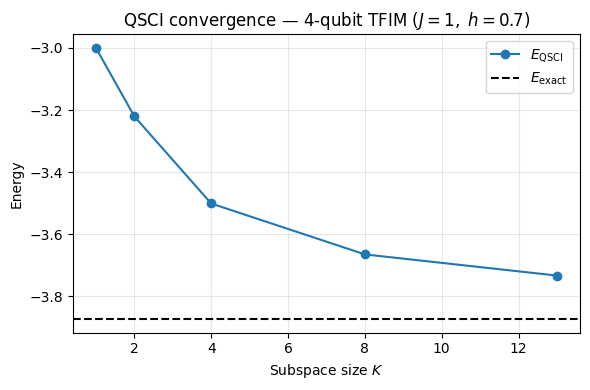

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, energies, "-o", label=r"$E_{\mathrm{QSCI}}$")
ax.axhline(E_exact, color="black", linestyle="--", label=r"$E_{\mathrm{exact}}$")
ax.set_xlabel("Subspace size $K$")
ax.set_ylabel("Energy")
ax.set_title("QSCI convergence — 4-qubit TFIM ($J{=}1,\\;h{=}0.7$)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The result confirms that the QSCI energy is monotonically non-increasing
with the subspace size $K$ and moves closer to the exact ground-state energy.

## Summary

In this tutorial, we used a four-qubit one-dimensional transverse-field Ising model to learn the QSCI workflow from its principles through its Qamomile implementation and accuracy evaluation.

- **QSCI** : QSCI samples an input quantum state in the computational basis, selects the most frequent bitstrings to define a subspace, and classically diagonalizes the Hamiltonian projected into that subspace. The resulting energy obeys the variational principle, so it remains an upper bound on the exact ground-state energy even when the input state is noisy or only roughly optimised.
- **Implementation with Qamomile** : We used Qamomile quantum kernels to implement VQE for preparing the input state and sampling it in the Z basis, then executed them through the QURI Parts integration. Qamomile's `qamomile.linalg.solve_subspace` constructs the effective Hamiltonian from sampled bitstrings and provides convenient access to the eigenvalues and eigenvectors obtained by classical diagonalization.
- **Subspace size and accuracy** : In the experiment with the four-qubit one-dimensional transverse-field Ising model, the QSCI energy remained above the exact reference and became monotonically non-increasing as the subspace size $K$ grew. Selecting more sampled bitstrings therefore produced a more expressive subspace and brought the energy estimate closer to the exact ground-state energy.